# Importing necessary libraries

In [15]:
from sklearn import  metrics
from sklearn.svm import SVC
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
from torch.utils.data import TensorDataset,DataLoader
from torch import optim
import torch.nn as nn
import torch

# Load Dataset

In [16]:
!gdown --id 1kFR51NiTY4mhb2j_7OqoDdj8cCiEcPHq
ds=pd.read_csv(r'ecg.csv',header=None)
data=ds.iloc[:,:-1].values
target=ds.iloc[:,-1].to_numpy()
ds=pd.read_csv(r'ecg.csv',header=None)
data=ds.iloc[:,:-1].values
target=ds.iloc[:,-1].to_numpy()

/usr/local/lib/python3.10/dist-packages/gdown/cli.py:138: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1kFR51NiTY4mhb2j_7OqoDdj8cCiEcPHq
To: /content/ecg.csv
100% 7.88M/7.88M [00:00<00:00, 222MB/s]


# Split data into train and test (70-30)

In [17]:
data_train,data_test,d_train,d_test= train_test_split(
     data,target,train_size=0.7,random_state=1)

# Feature extraction using principal component analysis (PCA)

In [18]:
pca= PCA(n_components=3)
pca.fit(data_train)
data_train= pca.transform(data_train)
data_test= pca.transform(data_test)

# Convert to tensor

In [19]:
data_train= torch.from_numpy(data_train).type(torch.float32)
d_train= torch.from_numpy(d_train).type(torch.float32)

data_test= torch.from_numpy(data_test).type(torch.float32)
d_test= torch.from_numpy(d_test).type(torch.float32)

# Bulid a data loader

In [20]:
ds= TensorDataset(data_train,d_train)
train_loader= DataLoader(ds,batch_size=32,shuffle=True)

# Design MLP Neural Network

In [21]:
class NeuralNetwork(nn.Module):
     def __init__(self,n_features,n_hid1,n_hid2,n_out):
          super(NeuralNetwork,self).__init__()
          self.lin1= nn.Linear(in_features=n_features,out_features=n_hid1)
          self.lin2= nn.Linear(in_features=n_hid1,out_features=n_hid2)
          self.lin3= nn.Linear(in_features=n_hid2,out_features=n_out)

          self.tanh= nn.Tanh()
          self.sigmoid= nn.Sigmoid()

     def forward(self,data):
          out= self.lin1(data)
          out=self.tanh(out)

          out= self.lin2(out)
          out=self.tanh(out)

          out= self.lin3(out)
          out= self.sigmoid(out)
          return out


# Create a Model using defined class

In [22]:
n_features= data_train.size(1)
n_hid1= 20
n_hid2= 10
n_out= 1
model= NeuralNetwork(n_features,n_hid1,n_hid2,n_out)

# Define the optimizer

In [23]:
# optimizer= optim.SGD(params=model.parameters(),lr=0.001)
# optimizer= optim.SGD(params=model.parameters(),lr=0.001,momentum=0.2)
optimizer= optim.Adam(params=model.parameters(),lr=0.001,betas=(0.9,0.999),eps= 1e-8)

# Cost function

In [24]:
criteria= nn.BCELoss()

# Train Neural Network

In [25]:
mse=[]
epoch=20
for iter in range(1,epoch):
     er=[]
     for xbatch,ybatch in train_loader:
          # farward pass
          ypred= model(xbatch)
          # backward pass
          loss=  criteria(ypred.flatten(),ybatch)
          loss.backward() # triger gradient calculation
          optimizer.step()# update parameters(synaptic wieghts)
          optimizer.zero_grad() # clear gradients

          er.append(loss.detach())

     loss= torch.mean(torch.tensor(er))
     mse.append(loss)
     print(f'MSE({iter-1}): {mse[iter-1]}')

mse=torch.tensor(mse)

MSE(0): 0.4085485339164734
MSE(1): 0.15331226587295532
MSE(2): 0.10203344374895096
MSE(3): 0.08295710384845734
MSE(4): 0.07490084320306778
MSE(5): 0.07070860266685486
MSE(6): 0.06753578782081604
MSE(7): 0.06560225784778595
MSE(8): 0.06458419561386108
MSE(9): 0.061991482973098755
MSE(10): 0.06095242500305176
MSE(11): 0.06274591386318207
MSE(12): 0.05991027504205704
MSE(13): 0.05856863409280777
MSE(14): 0.05821533501148224
MSE(15): 0.05757945403456688
MSE(16): 0.05699166655540466
MSE(17): 0.05678979307413101
MSE(18): 0.05695369839668274


# Test trained Neural Network

In [26]:
with torch.no_grad():
     ypred= model(data_test)
     ypred= torch.round(ypred)

# Calculate validation parameters

[[608  24]
 [  4 864]]
Accuracy:98.133%
Sensitivity:96.203%
Specificity:99.539%


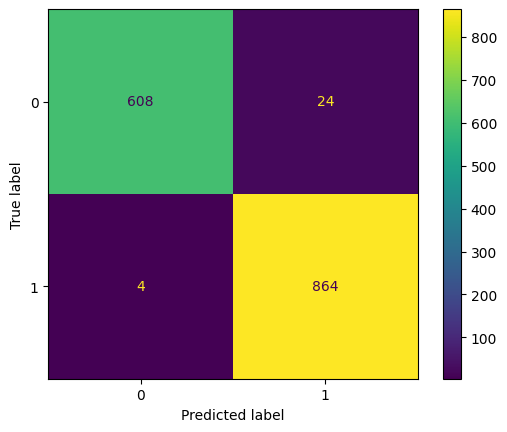

In [28]:
C= metrics.confusion_matrix(d_test.flatten(),ypred.flatten())
print(C)
accuracy= np.sum(np.diag(C))/ np.sum(C) *100
sensitivity= C[0,0]/ np.sum(C[0,:]) *100
specificity= C[1,1]/ np.sum(C[1,:]) *100
print(f'Accuracy:{accuracy:.3f}%')
print(f'Sensitivity:{sensitivity:.3f}%')
print(f'Specificity:{specificity:.3f}%')
disp= metrics.ConfusionMatrixDisplay(C)
disp.plot()
plt.show()